In [7]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot Settings
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [8]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("sales_cleaned.csv")

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (78350, 45)


In [9]:
# ==========================================
# DATE CONVERSION
# ==========================================

df['Inv.Date'] = pd.to_datetime(df['Inv.Date'])
df['Date'] = pd.to_datetime(df['Date'])

print("Date Conversion Completed")


Date Conversion Completed


In [10]:
# ==========================================
# DATA CHECK
# ==========================================

df.head()

,Customer Name,Customer Code,Ship To Cust Code,Ship To Cust Name,Bill Type,C,Inv.No,ODN,BUS. PLACE,SO.No,Date,Week,Incoterms,PO.No,PI.No,Cust.Nature,Territory Code,Territory,Inv.Date,Brand,Sub-Brand,Prime Brand,Folder/Non-Folder,Material,Material Desc.,Division,Division Text,Thickness,Vol.CBM,Design(LAM),Finish(LAM),Billed Qty,Sales unit,Billed Qty(SQM),Billed Qty(PCS),Billed Qty(NA),Billed Qty (CBM),Billed Qty (MT),Year,Month,Month_Name,Quarter,Day,Day_Name,Year_Month
0,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI055PC18300305O,5.5 MM CEN PLN MDF- DI-E2 C-1.83 X0.305,22,MDF - Plain,5.50,2.53,NaN,NaN,825,PC,460.51,825,0,2.53,2.00,2021,1,January,1,1,Friday,2021-01
1,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI070PC18300305O,7 MM CEN PLN MDF- DI-E2 C-1.83 X0.305,22,MDF - Plain,7.00,4.42,NaN,NaN,1131,PC,631.32,1131,0,4.42,3.49,2021,1,January,1,1,Friday,2021-01
2,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI110PC19830610O,11 MM CEN PLN MDF-DI-E2 C-1.983X0.61,22,MDF - Plain,11.00,8.12,NaN,NaN,610,PC,737.86,610,0,8.12,0.00,2021,1,January,1,1,Friday,2021-01
3,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI168PC18300610O,16.75 MM CEN PLN MDF- DI-E2 C-1.83 X0.61,22,MDF - Plain,16.75,6.67,NaN,NaN,357,PC,398.52,357,0,6.67,5.27,2021,1,January,1,1,Friday,2021-01
4,N.K. Traders,10016196,10016196,N.K. Traders,ZFAC,NaN,2027009169,F22027008891,PH01,1129145721,2021-01-01,1,Free on road,NaN,NaN,CD-customer,511995,Prelam -Jaipur,2021-01-01,NaN,NaN,NaN,NaN,HMCI168PC18300305O,16.75 MM CEN PLN MDF-DI-E2 C-1.83 X0.305,22,MDF - Plain,16.75,0.65,NaN,NaN,70,PC,39.07,70,0,0.65,0.52,2021,1,January,1,1,Friday,2021-01


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78350 entries, 0 to 78349
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer Name      78350 non-null  object        
 1   Customer Code      78350 non-null  int64         
 2   Ship To Cust Code  78350 non-null  int64         
 3   Ship To Cust Name  78350 non-null  object        
 4   Bill Type          78350 non-null  object        
 5   C                  1410 non-null   object        
 6   Inv.No             78350 non-null  int64         
 7   ODN                78350 non-null  object        
 8   BUS. PLACE         78350 non-null  object        
 9   SO.No              78350 non-null  int64         
 10  Date               78350 non-null  datetime64[ns]
 11  Week               78350 non-null  int64         
 12  Incoterms          78350 non-null  object        
 13  PO.No              0 non-null      float64       
 14  PI.No 

In [12]:
# ==========================================
# CREATE YEAR_MONTH
# ==========================================

if 'Year_Month' not in df.columns:
    
    df['Year_Month'] = (
        df['Inv.Date']
        .dt.to_period('M')
        .astype(str)
    )

print("Year_Month Ready")

Year_Month Ready


In [13]:
# ==========================================
# DASHBOARD COLOR PALETTE
# ==========================================

colors = sns.color_palette("Blues_r", 10)

In [14]:
total_volume = df['Billed Qty (CBM)'].sum()

total_customers = df['Customer Name'].nunique()

total_territories = df['Territory'].nunique()

total_materials = df['Material'].nunique()

print(f"Total Volume (CBM): {total_volume:,.2f}")
print(f"Total Customers: {total_customers}")
print(f"Total Territories: {total_territories}")
print(f"Total Materials: {total_materials}")

Total Volume (CBM): 175,154.16
Total Customers: 626
Total Territories: 69
Total Materials: 5055


In [15]:
monthly_volume = (
    df.groupby('Year_Month')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

monthly_volume

,Year_Month,Billed Qty (CBM)
0,2021-01,14898.69
1,2021-02,14174.11
2,2021-03,16677.11
3,2021-04,12617.54
4,2021-05,8130.64
5,2021-06,11017.35
6,2021-07,11908.40
7,2021-08,13785.52
8,2021-09,16253.70
9,2021-10,19481.49


In [16]:
monthly_volume['Growth_%'] = (
    monthly_volume['Billed Qty (CBM)']
    .pct_change() * 100
)

monthly_volume

,Year_Month,Billed Qty (CBM),Growth_%
0,2021-01,14898.69,NaN
1,2021-02,14174.11,-4.86
2,2021-03,16677.11,17.66
3,2021-04,12617.54,-24.34
4,2021-05,8130.64,-35.56
5,2021-06,11017.35,35.50
6,2021-07,11908.40,8.09
7,2021-08,13785.52,15.76
8,2021-09,16253.70,17.90
9,2021-10,19481.49,19.86


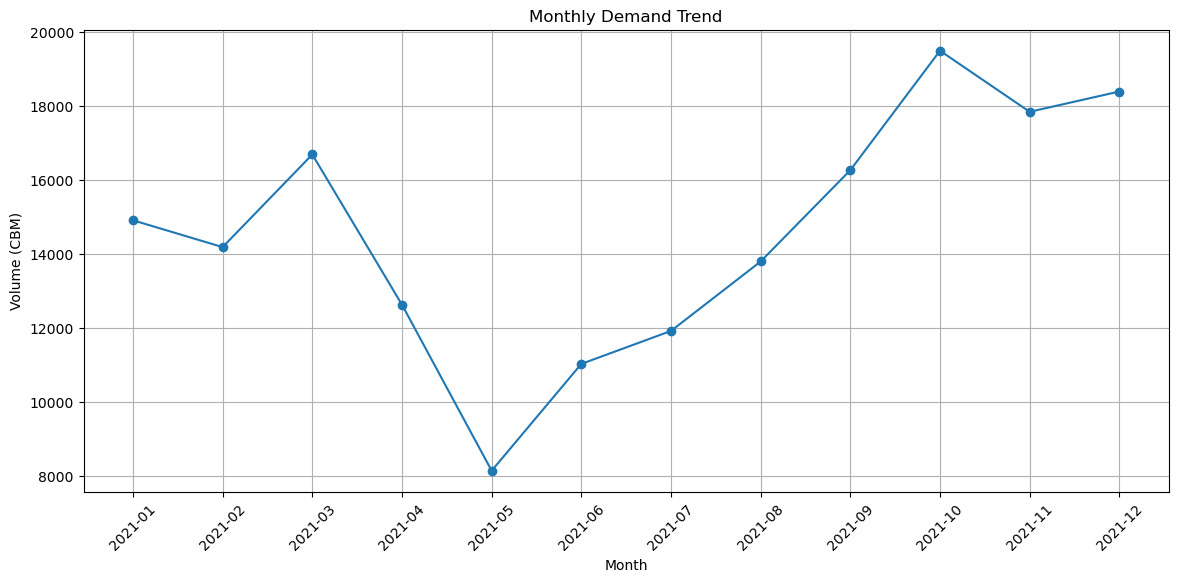

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_volume['Year_Month'],
    monthly_volume['Billed Qty (CBM)'],
    marker='o'
)

plt.title('Monthly Demand Trend')
plt.xlabel('Month')
plt.ylabel('Volume (CBM)')
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [18]:
territory_analysis = (
    df.groupby('Territory')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

territory_analysis['Contribution_%'] = (
    territory_analysis['Billed Qty (CBM)']
    /
    territory_analysis['Billed Qty (CBM)'].sum()
) * 100

territory_analysis = territory_analysis.sort_values(
    by='Billed Qty (CBM)',
    ascending=False
)

territory_analysis.head(10)

,Territory,Billed Qty (CBM),Contribution_%
45,Prelam -Ghaziabad,34389.52,19.63
44,Prelam -Delhi,26953.15,15.39
64,Prelam-Ludhiana,17911.58,10.23
49,Prelam -Jaipur,13037.91,7.44
46,Prelam -Gurgaon,8725.50,4.98
53,Prelam -Lucknow,8593.39,4.91
38,Prelam -Ahmedabad,6386.15,3.65
41,Prelam -Chennai,4803.80,2.74
54,Prelam -Mumbai,4748.27,2.71
30,Prejap1,3744.73,2.14


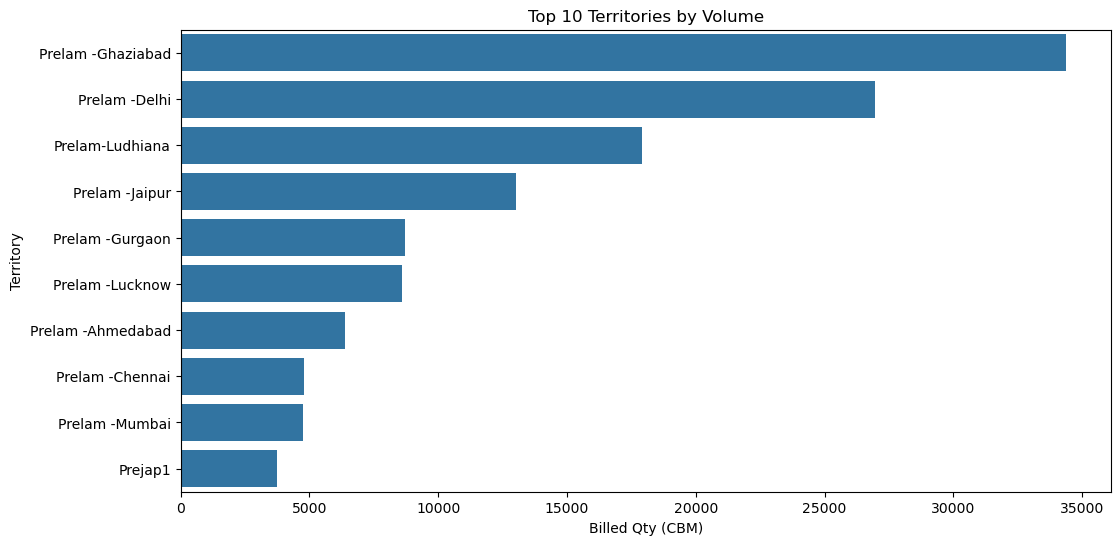

In [19]:
top_territories = territory_analysis.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_territories,
    x='Billed Qty (CBM)',
    y='Territory'
)

plt.title('Top 10 Territories by Volume')

plt.show()

In [20]:
customer_volume = (
    df.groupby('Customer Name')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
)

top10_share = (
    customer_volume.head(10).sum()
    /
    customer_volume.sum()
) * 100

top20_share = (
    customer_volume.head(20).sum()
    /
    customer_volume.sum()
) * 100

print(f"Top 10 Customers Contribution: {top10_share:.2f}%")
print(f"Top 20 Customers Contribution: {top20_share:.2f}%")

Top 10 Customers Contribution: 23.46%
Top 20 Customers Contribution: 34.26%


In [21]:
material_analysis = (
    df.groupby('Material Desc.')['Billed Qty (CBM)']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

material_analysis

Material Desc.
1.9 MM CEN PLN MDF-DI-E2- A-2.44X1.22      9669.89
11 MM CEN PLN MDF-DI-E2 A-2.44X1.22        7520.78
3.3 MM CEN PLN MDF-DI-E2 A-2.44X1.22       7354.07
16.75 MM CENPLAIN-PREMIUM+E2 A-2.44X1.22   6912.78
5.5 MM CEN PLN MDF-DI-E2 A-2.44X1.22       6542.82
16.5 MM CEN PLN MDF-DI-E2 A-2.44X1.22      5428.05
4.6 MM CEN PLN MDF-DI-E2 A-2.44X1.22       5140.06
18 MM CEN PLAIN-PREMIUM+ E2 A-2.44X1.22    5077.19
7 MM CEN PLN MDF-DI-E2 A-2.44X1.22         5028.82
16.75 MM PP E2 BB B008 BALWHITE MA8X4      3983.53
7.5 MM CEN PLN MDF-DI-E2 A-2.44X1.22       3965.23
16.75 MM PP E2 OB B008 BALWHITE MA8X4      3902.66
4 MM CENPLN MDF-DI-E2R A-2.44X1.22         3867.13
3.3 MM CEN PLN MDF-DW E2 A-2.44X1.22       3516.78
18 MM CENPLNMDF-DI-CARB P2 A-2.745X1.23    3480.57
11 MM CEN PLN MDF- DW E2 A-2.44 X1.22      2982.89
5.5 MM CEN PLN MDF- DW E2 A-2.44 X1.22     2831.64
16.5 MM CEN PLN MDF-DW E2 A-2.44X1.22      2735.23
2.1 MM CEN PLN MDF-DI-E2 A-2.44X1.22       2734.90
5.5 MM CEN PLAIN

In [22]:
thickness_analysis = (
    df.groupby('Thickness')['Billed Qty (CBM)']
      .sum()
      .reset_index()
)

thickness_analysis['Contribution_%'] = (
    thickness_analysis['Billed Qty (CBM)']
    /
    thickness_analysis['Billed Qty (CBM)'].sum()
) * 100

thickness_analysis.sort_values(
    by='Contribution_%',
    ascending=False
).head(10)

,Thickness,Billed Qty (CBM),Contribution_%
26,18.00,20655.17,11.79
24,16.75,20583.04,11.75
11,5.50,17073.38,9.75
16,11.00,15083.38,8.61
23,16.50,13305.62,7.60
6,3.30,11400.85,6.51
0,1.90,10564.24,6.03
13,7.50,8706.92,4.97
25,17.00,8475.93,4.84
10,4.60,6818.92,3.89


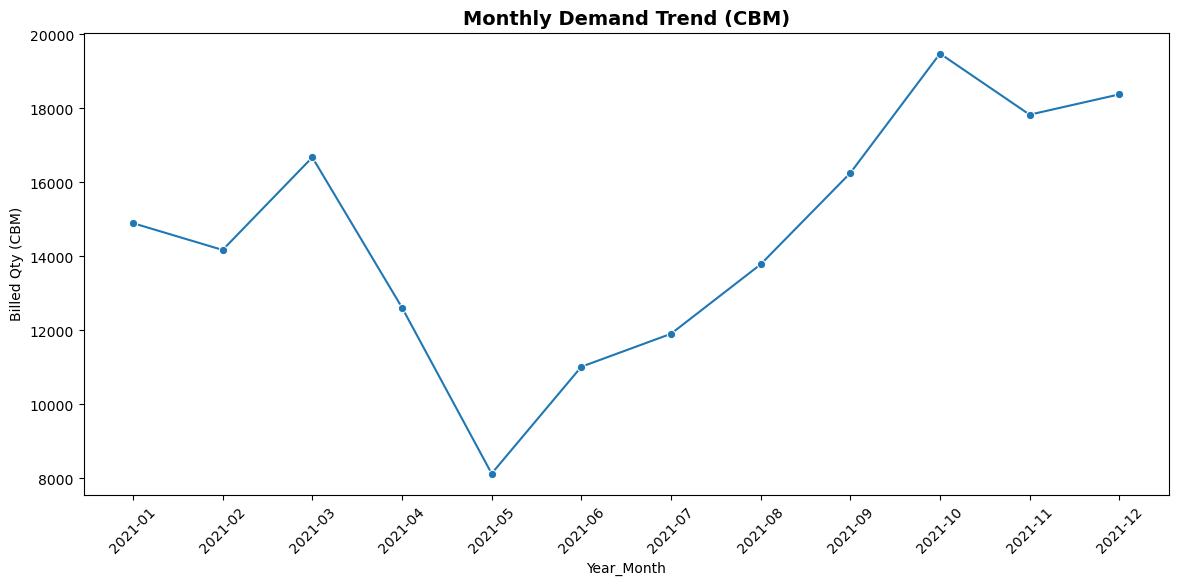

In [23]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_volume,
    x='Year_Month',
    y='Billed Qty (CBM)',
    marker='o'
)

plt.title(
    'Monthly Demand Trend (CBM)',
    fontsize=14,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.show()